In [1]:
import math
import os

import numpy as np
import torch
import torch.nn as nn
from diffusers.models import AutoencoderKL
from timm.models.vision_transformer import Attention, Mlp, PatchEmbed
from torchvision.datasets.utils import download_url
from torchvision.utils import save_image
from tqdm.auto import tqdm

/Users/alexh/remote/genmedia/minijourney/synthesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
CLASS_LABEL         = 207

IMAGE_SIZE          = 256
NUM_CLASSES         = 1000
VAE_VARIANT         = "mse"
NUM_SAMPLING_STEPS  = 50
SEED                = 9
CFG_SCALE           = 4.0

HIDDEN_SIZE         = 1152
DEPTH               = 28
NUM_HEADS           = 16
PATCH_SIZE          = 2
IN_CHANNELS         = 4

LATENT_SIZE         = IMAGE_SIZE // 8

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL CLASSES
# Defined here because PyTorch requires nn.Module subclasses to exist before
# you can instantiate or load weights into them. Instantiation is in step 0.2.
# ─────────────────────────────────────────────────────────────────────────────

class TimestepEmbedder(nn.Module):
    """
    Scalar timestep t -> 1D vector of size hidden_size.
      1. Sinusoidal encoding: t -> 256D (different frequencies per dimension,
         so every integer t maps to a unique fingerprint).
      2. Two-layer MLP with SiLU: 256 -> hidden_size.
    """
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    def forward(self, t):
        half  = self.frequency_embedding_size // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32) / half
        ).to(t.device)
        args   = t[:, None].float() * freqs[None]
        t_freq = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if self.frequency_embedding_size % 2:
            t_freq = torch.cat([t_freq, torch.zeros_like(t_freq[:, :1])], dim=-1)
        return self.mlp(t_freq)


class LabelEmbedder(nn.Module):
    """
    Integer class label -> 1D vector of size hidden_size.
    Lookup table of shape (num_classes + 1, hidden_size).
    The extra row at index num_classes is the unconditional embedding:
    during training, labels are randomly replaced with it at rate dropout_prob,
    teaching the model to generate without a class signal. At inference we
    explicitly pass num_classes for the unconditional CFG half.
    """
    def __init__(self, num_classes, hidden_size, dropout_prob):
        super().__init__()
        self.embedding_table = nn.Embedding(num_classes + (dropout_prob > 0), hidden_size)
        self.num_classes  = num_classes
        self.dropout_prob = dropout_prob

    def forward(self, labels, train, force_drop_ids=None):
        if (train and self.dropout_prob > 0) or force_drop_ids is not None:
            drop_ids = (
                torch.rand(labels.shape[0], device=labels.device) < self.dropout_prob
                if force_drop_ids is None
                else force_drop_ids == 1
            )
            labels = torch.where(drop_ids, self.num_classes, labels)
        return self.embedding_table(labels)


class DiTBlock(nn.Module):
    """
    One transformer block with adaLN-Zero conditioning.
    The conditioning vector c (= t_emb + y_emb) is projected to 6 scalars:
      shift_msa, scale_msa, gate_msa  -- modulate the self-attention sublayer
      shift_mlp, scale_mlp, gate_mlp  -- modulate the MLP sublayer
    Gates are initialized to 0 so each block starts as an identity transform.
    """
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0, **block_kwargs):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.attn  = Attention(hidden_size, num_heads=num_heads, qkv_bias=True, **block_kwargs)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.mlp   = Mlp(
            in_features=hidden_size,
            hidden_features=int(hidden_size * mlp_ratio),
            act_layer=lambda: nn.GELU(approximate="tanh"),
            drop=0,
        )
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True),
        )

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, \
        shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=1)
        x = x + gate_msa.unsqueeze(1) * self.attn(
            self.norm1(x) * (1 + scale_msa.unsqueeze(1)) + shift_msa.unsqueeze(1)
        )
        x = x + gate_mlp.unsqueeze(1) * self.mlp(
            self.norm2(x) * (1 + scale_mlp.unsqueeze(1)) + shift_mlp.unsqueeze(1)
        )
        return x


class FinalLayer(nn.Module):
    """
    Applied once after all 28 DiT blocks.
    Same adaLN conditioning as DiTBlock but no attention/MLP — just a single
    linear projection: hidden_size -> patch_size^2 * out_channels.
    Output is then unpatchified back into a spatial tensor.
    """
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.linear     = nn.Linear(hidden_size, patch_size * patch_size * out_channels, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size, bias=True),
        )

    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = self.norm_final(x) * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)
        return self.linear(x)


class DiT(nn.Module):
    """
    Full Diffusion Transformer.

    forward(x, t, y):
      1. Patchify + embed x + add pos_embed  ->  (B, num_patches, hidden_size)
      2. t_emb = TimestepEmbedder(t)         ->  (B, hidden_size)
      3. y_emb = LabelEmbedder(y)            ->  (B, hidden_size)
      4. c = t_emb + y_emb                   ->  conditioning vector
      5. 28x DiTBlock(x, c)
      6. FinalLayer -> unpatchify            ->  (B, out_channels, H, W)

    forward_with_cfg(x, t, y, cfg_scale):
      Runs conditional + unconditional halves in one batch, then blends:
        eps = uncond_eps + cfg_scale * (cond_eps - uncond_eps)
    """
    def __init__(
        self,
        input_size=32,
        patch_size=2,
        in_channels=4,
        hidden_size=1152,
        depth=28,
        num_heads=16,
        mlp_ratio=4.0,
        class_dropout_prob=0.1,
        num_classes=1000,
        learn_sigma=True,
    ):
        super().__init__()
        self.learn_sigma  = learn_sigma
        self.in_channels  = in_channels
        self.out_channels = in_channels * 2 if learn_sigma else in_channels
        self.patch_size   = patch_size
        self.num_heads    = num_heads

        self.x_embedder  = PatchEmbed(input_size, patch_size, in_channels, hidden_size, bias=True)
        self.t_embedder  = TimestepEmbedder(hidden_size)
        self.y_embedder  = LabelEmbedder(num_classes, hidden_size, class_dropout_prob)
        self.pos_embed   = nn.Parameter(
            torch.zeros(1, self.x_embedder.num_patches, hidden_size), requires_grad=False
        )
        self.blocks      = nn.ModuleList([
            DiTBlock(hidden_size, num_heads, mlp_ratio=mlp_ratio) for _ in range(depth)
        ])
        self.final_layer = FinalLayer(hidden_size, patch_size, self.out_channels)
        self.initialize_weights()

    def initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

        embed_dim = self.pos_embed.shape[-1]
        grid_size = int(self.x_embedder.num_patches ** 0.5)
        grid      = np.stack(
            np.meshgrid(np.arange(grid_size, dtype=np.float32),
                        np.arange(grid_size, dtype=np.float32)), axis=0
        ).reshape([2, 1, grid_size, grid_size])
        half  = embed_dim // 2
        omega = 1.0 / 10000 ** (np.arange(half // 2, dtype=np.float64) / (half / 2.0))
        emb_h = np.concatenate([np.sin(np.einsum("m,d->md", grid[0].reshape(-1), omega)),
                                 np.cos(np.einsum("m,d->md", grid[0].reshape(-1), omega))], axis=1)
        emb_w = np.concatenate([np.sin(np.einsum("m,d->md", grid[1].reshape(-1), omega)),
                                 np.cos(np.einsum("m,d->md", grid[1].reshape(-1), omega))], axis=1)
        self.pos_embed.data.copy_(
            torch.from_numpy(np.concatenate([emb_h, emb_w], axis=1)).float().unsqueeze(0)
        )

        w = self.x_embedder.proj.weight.data
        nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        nn.init.constant_(self.x_embedder.proj.bias, 0)
        nn.init.normal_(self.y_embedder.embedding_table.weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)
        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias,   0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias,   0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias,   0)

    def forward(self, x, t, y):
        x = self.x_embedder(x) + self.pos_embed
        t = self.t_embedder(t)
        y = self.y_embedder(y, self.training)
        c = t + y
        for block in self.blocks:
            x = block(x, c)
        x = self.final_layer(x, c)
        p = self.x_embedder.patch_size[0]
        h = w = int(x.shape[1] ** 0.5)
        x = x.reshape(x.shape[0], h, w, p, p, self.out_channels)
        x = torch.einsum("nhwpqc->nchpwq", x)
        return x.reshape(x.shape[0], self.out_channels, h * p, h * p)

    def forward_with_cfg(self, x, t, y, cfg_scale):
        half      = x[: len(x) // 2]
        combined  = torch.cat([half, half], dim=0)
        model_out = self.forward(combined, t, y)
        eps, rest            = model_out[:, :self.in_channels], model_out[:, self.in_channels:]
        cond_eps, uncond_eps = torch.split(eps, len(eps) // 2, dim=0)
        half_eps             = uncond_eps + cfg_scale * (cond_eps - uncond_eps)
        return torch.cat([torch.cat([half_eps, half_eps], dim=0), rest], dim=1)

In [4]:
torch.manual_seed(SEED)
torch.set_grad_enabled(False)
device = "cpu"

In [5]:
# load pretrained DiT-XL/2 — EMA weights are smoother than raw training weights
# and produce better samples at inference

ckpt_name  = f"DiT-XL-2-{IMAGE_SIZE}x{IMAGE_SIZE}.pt"
local_path = f"pretrained_models/{ckpt_name}"

if not os.path.isfile(local_path):
    os.makedirs("pretrained_models", exist_ok=True)
    download_url(f"https://dl.fbaipublicfiles.com/DiT/models/{ckpt_name}", "pretrained_models")

state_dict = torch.load(local_path, map_location=lambda storage, loc: storage)
if "ema" in state_dict:
    state_dict = state_dict["ema"]

model = DiT(
    input_size=LATENT_SIZE,
    num_classes=NUM_CLASSES,
    depth=DEPTH,
    hidden_size=HIDDEN_SIZE,
    patch_size=PATCH_SIZE,
    num_heads=NUM_HEADS,
).to(device)
model.load_state_dict(state_dict)
model.eval()

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(4, 1152, kernel_size=(2, 2), stride=(2, 2))
    (norm): Identity()
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1152, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1152, out_features=1152, bias=True)
    )
  )
  (y_embedder): LabelEmbedder(
    (embedding_table): Embedding(1001, 1152)
  )
  (blocks): ModuleList(
    (0-27): 28 x DiTBlock(
      (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1152, out_features=3456, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=1152, out_features=1152, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (mlp): Mlp(
        (

In [6]:
# DiT works in latent space (32x32x4), not pixel space (256x256x3).
# the VAE from Stable Diffusion decompresses latents back to pixels.
# only called once, after the denoising loop finishes.

vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-{VAE_VARIANT}").to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/Users/alexh/remote/genmedia/minijourney/synthesis/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


---
Say we have a set of classes (ex: "cat", "dog", "toothbrush") and a set of images corresponding to each class. We want an AI model that generates photorealistic images given a class label.

---
let's break the problem into smaller pieces. instead of generating an image in one pass, we can train a model that, given a noisy image, outputs an image that is slightly less noisy. then, if we repeat this process many times, we will get a clear image. here is a preview of what that looks like:

![Alt text](assets/2t.png)
![Alt text](assets/34t.png)
![Alt text](assets/t.png)

_DiT sampling at $\frac{T}{2}, \frac{3T}{4}$, and $T$ steps_

---
consider a forward process that corrupts a clean image $\mathbf{x}_0$ into noise over $T=1000$ steps. at each step $t$, a small amount of Gaussian noise is added:

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \sqrt{1 - \beta_t} \, \mathbf{x}_{t-1} + \sqrt{\beta_t} \, \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

$\beta_t$ is a small number increasing linearly from $0.0001$ to $0.02$ — more noise added in later steps when the image is already mostly corrupted.

to generate an image, we start from complete noise and run this process in reverse:

$$
\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

$$
\mathbf{x}_{t-1} \sim p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \text{label})
$$

until $\mathbf{x}_0$ is a clean image. our goal is to derive what $p_\theta$ needs to compute at each step.

---
we want to sample $\mathbf{x}_{t-1}$ given only $\mathbf{x}_t$ and the label. by the law of total probability, marginalizing over all possible clean images $\mathbf{x}_0$:

$$
q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \text{label}) = \int q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0)\, q(\mathbf{x}_0 \mid \mathbf{x}_t, \text{label})\, d\mathbf{x}_0
$$

$q(\mathbf{x}_0 \mid \mathbf{x}_t, \text{label})$ requires knowing the full data distribution — intractable. instead, substitute the model's point estimate $\hat{\mathbf{x}}_0^{\,\theta}(\mathbf{x}_t, t, \text{label})$:

$$
\approx q\!\left(\mathbf{x}_{t-1} \mid \mathbf{x}_t,\, \mathbf{x}_0 = \hat{\mathbf{x}}_0^{\,\theta}(\mathbf{x}_t, t, \text{label})\right)
$$

apply bayes rule, then use the markov property ($\mathbf{x}_t$ depends only on $\mathbf{x}_{t-1}$, not on $\hat{\mathbf{x}}_0$ given $\mathbf{x}_{t-1}$):

$$
= \frac{q(\mathbf{x}_t \mid \mathbf{x}_{t-1})\, q(\mathbf{x}_{t-1} \mid \hat{\mathbf{x}}_0)}{q(\mathbf{x}_t \mid \hat{\mathbf{x}}_0)}
$$

each term is a gaussian from the forward process. $q(\mathbf{x}_t \mid \mathbf{x}_{t-1})$ is the single-step definition. $q(\mathbf{x}_{t-1} \mid \hat{\mathbf{x}}_0)$ and $q(\mathbf{x}_t \mid \hat{\mathbf{x}}_0)$ come from the closed form $q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}(\sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\ (1-\bar{\alpha}_t)\mathbf{I})$ where $\bar{\alpha}_t = \prod_{i=0}^{t}(1-\beta_i)$:

$$
= \frac{\mathcal{N}(\mathbf{x}_t;\ \sqrt{\alpha_t}\,\mathbf{x}_{t-1},\ \beta_t\mathbf{I})\cdot\mathcal{N}(\mathbf{x}_{t-1};\ \sqrt{\bar{\alpha}_{t-1}}\,\hat{\mathbf{x}}_0,\ (1-\bar{\alpha}_{t-1})\mathbf{I})}{\mathcal{N}(\mathbf{x}_t;\ \sqrt{\bar{\alpha}_t}\,\hat{\mathbf{x}}_0,\ (1-\bar{\alpha}_t)\mathbf{I})}
$$

the denominator has no $\mathbf{x}_{t-1}$, absorb into proportionality. expanding and grouping by powers of $\mathbf{x}_{t-1}$:

$$
\propto \exp\!\left(-\frac{1}{2}\left[\mathbf{x}_{t-1}^2\underbrace{\left(\frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}}\right)}_{1/\tilde{\beta}_t} - 2\mathbf{x}_{t-1}\underbrace{\left(\frac{\sqrt{\alpha_t}}{\beta_t}\mathbf{x}_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}\hat{\mathbf{x}}_0\right)}_{\tilde{\mu}_t/\tilde{\beta}_t}\right]\right)
$$

this is the kernel of a gaussian. reading off the variance and mean:

$$
\tilde{\beta}_t = \beta_t\cdot\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t} \qquad\qquad \tilde{\mu}_t = \frac{\beta_t\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_t}\hat{\mathbf{x}}_0 + \frac{(1-\bar{\alpha}_{t-1})\sqrt{\alpha_t}}{1-\bar{\alpha}_t}\mathbf{x}_t
$$

$$
\therefore \quad \mathbf{x}_{t-1} = \tilde{\mu}_t + \sqrt{\tilde{\beta}_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

in code this is:

```python
mean = spaced_post_coef1[i] * pred_xstart + spaced_post_coef2[i] * img
img  = mean + torch.exp(0.5 * log_variance) * torch.randn_like(img)
```

to compute this we need $\tilde{\mu}_t$ and $\tilde{\beta}_t$ at each of our 50 steps — both are functions of $\beta_t$ and $\bar{\alpha}_t$. the code below derives those.

---
$\beta_t$ increases linearly — more noise is added in later steps when the image is already mostly corrupted:

In [7]:
all_beta_values = np.linspace(0.0001, 0.02, 1000, dtype=np.float64)

---
running all 1000 reverse steps sequentially at inference is slow. we use 50 evenly-spaced steps instead:

In [8]:
used_timesteps = np.linspace(0, 999, 50, dtype=int)

---
$\alpha_t = 1 - \beta_t$ is the fraction of signal retained in one step. $\bar{\alpha}_t = \prod_{i=0}^{t} \alpha_i$ is the cumulative signal fraction after $t$ steps — close to $1.0$ at $t=0$, close to $0.0$ at $t=999$:

$$
\bar{\alpha}_t = \prod_{i=0}^{t}(1 - \beta_i)
$$

In [9]:
all_alpha_values  = 1 - all_beta_values
all_signal_values = np.cumprod(all_alpha_values)   # ᾱ_t for t = 0…999

---
each $\beta_t$ was defined for a single-step transition — it only accounts for noise added in that one step. skipping 20 steps at a time means we need the effective $\beta$ for the entire jump. from the closed form, the signal ratio between two selected steps $t_\text{prev}$ and $t$ gives:

$$
\tilde{\beta} = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t_\text{prev}}}
$$

In [10]:
signal_values_used    = all_signal_values[used_timesteps]
signal_prev_timesteps = np.concatenate([[1.0], signal_values_used[:-1]])  # ᾱ_{t_prev}, with 1.0 at the boundary

spaced_signals = signal_values_used / signal_prev_timesteps   # ᾱ_t / ᾱ_{t_prev}
spaced_betas   = 1 - spaced_signals

---
from the derived posterior formulas, precompute all coefficients for the 50 selected steps.

$\hat{\mathbf{x}}_0$ is recovered each step from the model's noise prediction $\epsilon_\theta$. rearranging the forward process equation $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon$:

$$
\hat{\mathbf{x}}_0 = \underbrace{\frac{1}{\sqrt{\bar{\alpha}_t}}}_{\texttt{sqrt\_recip}} \mathbf{x}_t - \underbrace{\sqrt{\frac{1}{\bar{\alpha}_t}-1}}_{\texttt{sqrt\_recipm1}}\, \epsilon_\theta
$$

the posterior variance $\tilde{\beta}_t$ is fixed by the schedule. Nichol & Dhariwal (2021) showed that letting the model predict the variance improves quality — the model outputs $v \in [-1,1]$ that interpolates between a lower bound $\log \tilde{\beta}_t$ and upper bound $\log \beta_t$:

$$
\log \sigma^2_t = v \cdot \log \beta_t + (1 - v) \cdot \log \tilde{\beta}_t
$$

In [11]:
spaced_ac      = np.cumprod(spaced_signals)               # ᾱ over the 50 spaced steps
spaced_ac_prev = np.concatenate([[1.0], spaced_ac[:-1]])  # ᾱ_{t-1}
spaced_alphas  = 1 - spaced_betas

# coefficients to recover x_0 from x_t and predicted noise
spaced_sqrt_recip   = np.sqrt(1.0 / spaced_ac)
spaced_sqrt_recipm1 = np.sqrt(1.0 / spaced_ac - 1)

# posterior mean coefficients: mean = coef1 * x_0_hat + coef2 * x_t
spaced_post_coef1 = spaced_betas * np.sqrt(spaced_ac_prev) / (1.0 - spaced_ac)
spaced_post_coef2 = (1.0 - spaced_ac_prev) * np.sqrt(spaced_alphas) / (1.0 - spaced_ac)

# variance bounds for learned variance interpolation
spaced_post_var     = spaced_betas * (1.0 - spaced_ac_prev) / (1.0 - spaced_ac)
spaced_post_log_var = np.log(np.append(spaced_post_var[1], spaced_post_var[1:]))  # lower bound, clip i=0 to avoid log(0)
spaced_log_betas    = np.log(spaced_betas)                                         # upper bound

---
the reverse process starts from pure Gaussian noise in the VAE's latent space — a $(4, 32, 32)$ tensor with no signal:

$$
\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

classifier-free guidance requires two parallel forward passes per step — one conditional (real label) and one unconditional (null label, index 1000). we batch both so one model call handles both:
- `img`: $(2, 4, 32, 32)$ — two copies of the same starting noise
- `y`: $(2,)$ — `[207, 1000]`

In [12]:
noise_tensor = torch.randn(1, IN_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=device)  # (1, 4, 32, 32)

img = torch.cat([noise_tensor, noise_tensor], dim=0)          # (2, 4, 32, 32)
y   = torch.tensor([CLASS_LABEL, NUM_CLASSES], device=device)

---
each iteration applies the posterior sampling formula once, stepping $\mathbf{x}_t \to \mathbf{x}_{t-1}$:

1. run the model to get predicted noise $\epsilon_\theta$ and raw variance $v$
2. recover $\hat{\mathbf{x}}_0$ from $\epsilon_\theta$
3. compute posterior mean $\tilde{\mu}_t$ from $\hat{\mathbf{x}}_0$ and $\mathbf{x}_t$
4. sample $\mathbf{x}_{t-1} = \tilde{\mu}_t + \sqrt{\sigma^2_t}\,\epsilon$

no noise is added on the final step ($i=0$) for a deterministic last step.

In [13]:
for i in tqdm(reversed(range(NUM_SAMPLING_STEPS))):

    # tell the model which original 0-999 timestep this spaced step corresponds to
    t_batch = torch.tensor([used_timesteps[i]] * img.shape[0], device=device)

    # model outputs: first IN_CHANNELS = predicted noise, next IN_CHANNELS = raw variance in [-1, 1]
    model_out        = model.forward_with_cfg(img, t_batch, y=y, cfg_scale=CFG_SCALE)
    model_eps        = model_out[:, :IN_CHANNELS]
    model_var_values = model_out[:, IN_CHANNELS:]

    # interpolate log-variance between posterior lower bound and beta upper bound
    frac         = (model_var_values + 1) / 2   # rescale [-1, 1] -> [0, 1]
    log_variance = frac * float(spaced_log_betas[i]) + (1 - frac) * float(spaced_post_log_var[i])

    # recover x_0 estimate: x_t = sqrt(ᾱ)*x_0 + sqrt(1-ᾱ)*eps  =>  solve for x_0
    pred_xstart = float(spaced_sqrt_recip[i]) * img - float(spaced_sqrt_recipm1[i]) * model_eps

    # posterior mean and sample x_{t-1}
    mean  = float(spaced_post_coef1[i]) * pred_xstart + float(spaced_post_coef2[i]) * img
    noise = torch.randn_like(img)
    img   = mean + (0.0 if i == 0 else 1.0) * torch.exp(0.5 * log_variance) * noise

0it [00:00, ?it/s]

50it [00:14,  3.41it/s]


---
`img` is $(2, 4, 32, 32)$ — conditional and unconditional samples batched together. keep only the conditional half, decode through the VAE to pixel space. dividing by $0.18215$ undoes the latent scaling applied during VAE training.

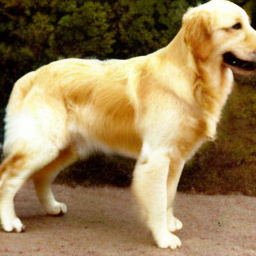

In [14]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

samples = img.chunk(2, dim=0)[0]                    # (1, 4, 32, 32) — conditional only
samples = vae.decode(samples / 0.18215).sample      # (1, 3, 256, 256)

# normalize from [-1, 1] to [0, 1] and display
samples = (samples.clamp(-1, 1) + 1) / 2
display(to_pil_image(samples[0].cpu()))